# Sentiment Analysis using RNN, LSTM & GRU
### IMDb Movie Reviews Dataset — Theory, Mathematics, Implementation & Comparison

**Objective:** Build, train and compare three recurrent architectures — **Simple RNN**, **LSTM**, and **GRU** — for binary sentiment classification (positive / negative) on the IMDb 50,000 movie review dataset, and analyse *why* one architecture outperforms the others.

**Contents**

1. [Theory: Sentiment Analysis & Sequence Models](#1)
2. [Theory: Simple RNN (with mathematics & diagram)](#2)
3. [Theory: The Vanishing Gradient Problem](#3)
4. [Theory: LSTM (with mathematics & diagram)](#4)
5. [Theory: GRU (with mathematics & diagram)](#5)
6. [Setup & Imports](#6)
7. [Data Loading](#7)
8. [Data Preprocessing (Cleaning → Tokenization → Vocabulary → Sequences → Padding)](#8)
9. [Exploratory Visualizations](#9)
10. [Model Building (RNN, LSTM, GRU)](#10)
11. [Training](#11)
12. [Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)](#12)
13. [Comparison Table & Charts](#13)
14. [Analysis & Conclusions](#14)


<a id="1"></a>
## 1. Theory: Sentiment Analysis & Sequence Models

**Sentiment Analysis** (opinion mining) is the NLP task of determining whether a piece of text expresses a **positive**, **negative** (or neutral) opinion. For movie reviews, this is a **binary classification** problem: `1 = positive`, `0 = negative`.

### Why sequence models (RNN family) instead of plain feed-forward networks?

Text is inherently **sequential** — the meaning of a word depends on the words before it ("not good" vs "good"). A plain feed-forward / bag-of-words model treats words independently and loses this order information. **Recurrent Neural Networks (RNNs)** process a sequence one token at a time while maintaining a **hidden state** that acts as a memory of everything seen so far, which makes them naturally suited to text.

### General pipeline for this project

```
Raw Review Text
     │
     ▼
Text Cleaning (lowercase, remove HTML/punctuation/noise)
     │
     ▼
Tokenization (split into words)
     │
     ▼
Vocabulary Building (word → integer index)
     │
     ▼
Sequence Conversion (words → integer IDs)
     │
     ▼
Padding / Truncation (fixed length input)
     │
     ▼
Embedding Layer (integer IDs → dense vectors)
     │
     ▼
Recurrent Layer  (SimpleRNN / LSTM / GRU)
     │
     ▼
Dense + Sigmoid → P(positive)
```


<a id="2"></a>
## 2. Theory: Simple Recurrent Neural Network (RNN)

A Simple RNN maintains a hidden state $h_t$ that is updated at every time step $t$ using the current input $x_t$ and the *previous* hidden state $h_{t-1}$:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b_h)$$

$$\hat{y}_t = \sigma(W_y h_t + b_y)$$

Where:
- $x_t$ — input vector (word embedding) at time step $t$
- $h_{t-1}$ — hidden state (memory) from the previous step
- $W_x, W_h, W_y$ — learnable weight matrices (**shared across every time step**)
- $\tanh$ — squashes values to $(-1, 1)$, introduces non-linearity
- $\sigma$ — sigmoid, used for the final probability output

**Key property — weight sharing:** the *same* $W_x$ and $W_h$ are reused at every time step, which is what allows an RNN to process sequences of any length with a fixed number of parameters.

### Weakness: short-term memory
Because the same weight matrix $W_h$ is multiplied repeatedly across many time steps, gradients during backpropagation-through-time (BPTT) either **shrink toward zero** (vanish) or **blow up** (explode) over long sequences. This makes Simple RNNs poor at capturing **long-range dependencies** — exactly the kind of long, nuanced context found in movie reviews.


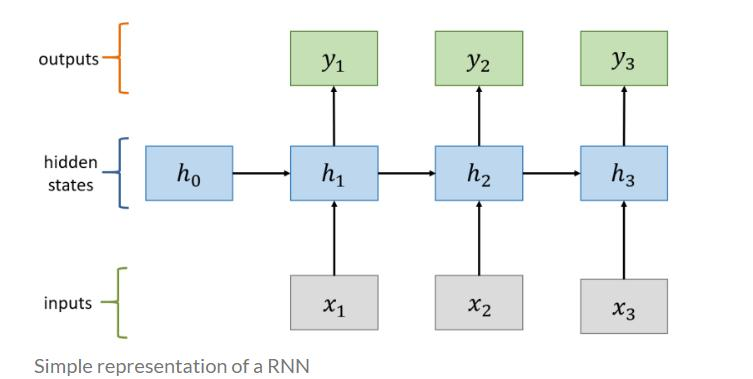

In [29]:
from IPython.display import Image, display
display(Image(filename="diagrams/rnn.png"))

<a id="3"></a>
## 3. The Vanishing Gradient Problem

During training, the gradient of the loss $\mathcal{L}$ with respect to an early hidden state is a **product of many Jacobians**:

$$\frac{\partial \mathcal{L}}{\partial h_1} = \frac{\partial \mathcal{L}}{\partial h_T}\prod_{t=2}^{T}\frac{\partial h_t}{\partial h_{t-1}}$$

Since each term $\frac{\partial h_t}{\partial h_{t-1}}$ involves $\tanh'(\cdot) \cdot W_h$, and $\tanh' \le 1$, repeated multiplication over long sequences ($T$ large) causes this product to **shrink exponentially toward 0** (vanishing) — or, if $\|W_h\|$ is large, to **grow exponentially** (exploding).

**Consequence:** Simple RNNs effectively "forget" information from early in a long review by the time they reach the end of it. This directly motivates **LSTM** and **GRU**, which introduce *gating mechanisms* and an (almost) additive memory path so gradients can flow across many time steps without vanishing.


<a id="4"></a>
## 4. Theory: Long Short-Term Memory (LSTM)

LSTM (Hochreiter & Schmidhuber, 1997) solves the vanishing-gradient problem by adding a separate **cell state** $C_t$ (a "conveyor belt" of memory) alongside the hidden state $h_t$, regulated by three **gates**: forget, input, and output.

**1. Forget Gate** — decides what to discard from the cell state:
$$f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$$

**2. Input Gate** — decides what new information to add:
$$i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C[h_{t-1}, x_t] + b_C)$$

**3. Cell State Update** — combines old memory (filtered by $f_t$) with new candidate memory (filtered by $i_t$):
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**4. Output Gate** — decides what part of the cell state becomes the hidden state:
$$o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

Where $\sigma$ = sigmoid (outputs values in $[0,1]$, acting as a "gate" that lets 0–100% of information through), and $\odot$ = element-wise multiplication.

**Why it works:** the cell-state update $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ is largely **additive**, not purely multiplicative like Simple RNN's $h_t$. This creates a near-uninterrupted gradient path across time steps, letting LSTM retain information over much longer sequences.


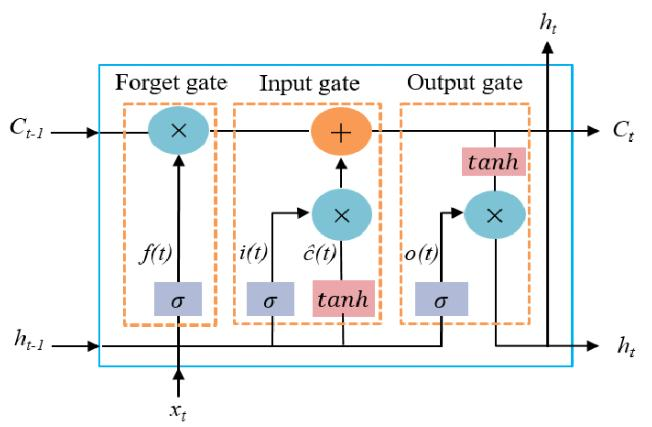

In [30]:
from IPython.display import Image, display
display(Image(filename="diagrams/lstm.png"))

<a id="5"></a>
## 5. Theory: Gated Recurrent Unit (GRU)

GRU (Cho et al., 2014) is a simplified alternative to LSTM. It merges the cell state and hidden state into one, and uses only **two gates** instead of three — making it faster to train with fewer parameters.

**1. Update Gate** — how much of the past to keep vs. how much new content to add (combines LSTM's forget + input gates):
$$z_t = \sigma(W_z[h_{t-1}, x_t] + b_z)$$

**2. Reset Gate** — how much past information to forget when computing the new candidate:
$$r_t = \sigma(W_r[h_{t-1}, x_t] + b_r)$$

**3. Candidate Activation:**
$$\tilde{h}_t = \tanh(W[r_t \odot h_{t-1}, x_t] + b)$$

**4. Final Hidden State** (linear interpolation between old state and candidate):
$$h_t = (1 - z_t)\odot h_{t-1} + z_t \odot \tilde{h}_t$$

**LSTM vs GRU parameter count:** LSTM has 4 weight matrix sets (forget, input, candidate, output) → roughly $4 \times (n \cdot m + n^2 + n)$ parameters per layer; GRU has only 3 → roughly $3 \times (n \cdot m + n^2 + n)$, where $n$ = hidden size, $m$ = input size. This makes **GRU ~25% lighter and typically faster to train** than LSTM, often with comparable accuracy.


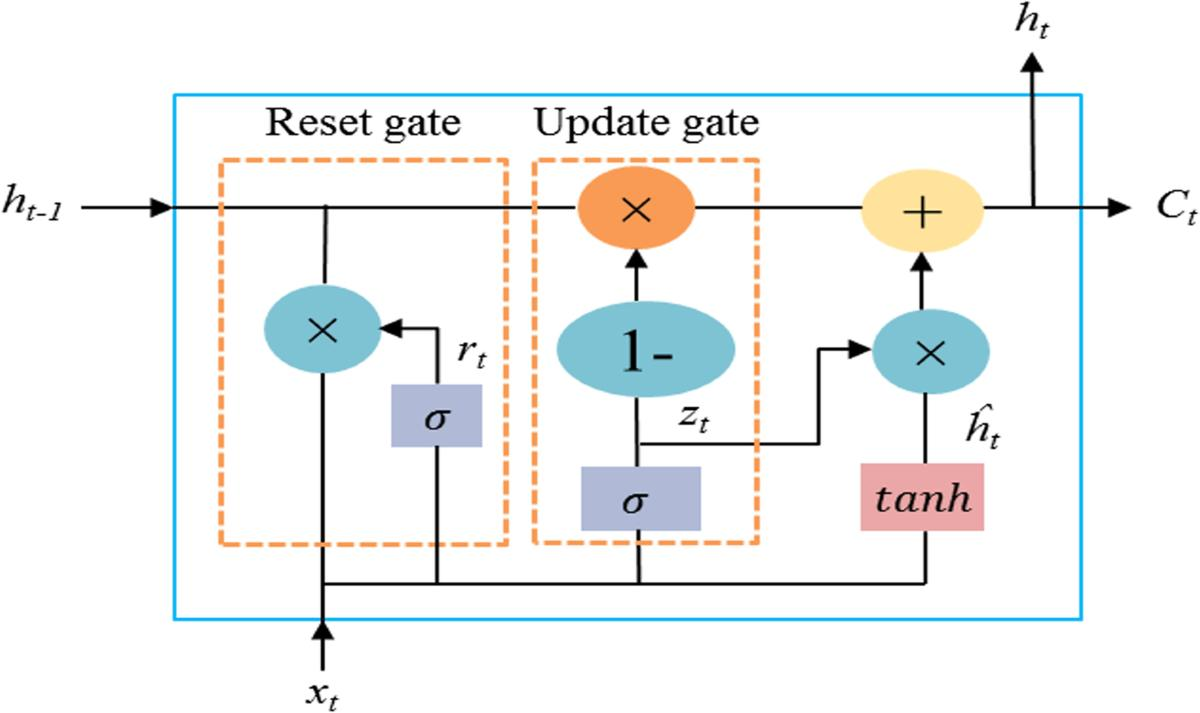

In [31]:
from IPython.display import Image, display
display(Image(filename="diagrams/gru.png"))

### Quick Theory Comparison

| Aspect | Simple RNN | LSTM | GRU |
|---|---|---|---|
| Memory mechanism | Single hidden state $h_t$ | Hidden state $h_t$ + cell state $C_t$ | Single hidden state $h_t$ |
| Gates | None | Forget, Input, Output (3) | Update, Reset (2) |
| Long-range dependency handling | Poor (vanishing gradients) | Excellent | Very good |
| Parameters (relative) | Fewest | Most | ~25% fewer than LSTM |
| Training speed | Fastest (but least useful) | Slowest | Faster than LSTM |
| Typical use case | Short sequences | Long, complex sequences | Long sequences, limited compute |


<a id='6'></a>
## 6. Setup & Imports

In [32]:
!pip install seaborn

In [33]:
!pip install seaborn matplotlib pandas numpy scikit-learn nltk tensorflow

In [34]:
!pip install seaborn

In [35]:
import sys
!{sys.executable} -m pip install seaborn matplotlib pandas numpy scikit-learn nltk tensorflow

In [36]:
# Core libraries
import re
import time
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


<a id="7"></a>
## 7. Data Loading — IMDb Movie Reviews Dataset (local CSV)

We use the standard **IMDb dataset** (50,000 reviews, perfectly balanced: 25,000 positive / 25,000 negative), supplied as a local CSV with two columns: `review` (raw text) and `sentiment` (`positive` / `negative`).

Place the CSV in the **same folder as this notebook** (as in the project's `4th week/` folder) before running. The loader below checks a few common filenames automatically.


In [37]:
import os

# Try the common filenames this dataset is usually saved under
candidate_paths = [
    "IMDB_MOVIE_dataset.csv",
    "IMDB MOVIE dataset.csv",
    "IMDB Dataset.csv",
    "imdb_dataset.csv",
]

csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find the IMDB CSV in the current folder. "
        "Update `csv_path` below to point at your file, e.g. csv_path = 'IMDB_MOVIE_dataset.csv'"
    )

df = pd.read_csv(csv_path)
print("Loaded:", csv_path)

# Map text labels -> 0/1
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("Total reviews:", len(df))
print(df["sentiment"].value_counts())
df.head()

Loaded: IMDB MOVIE dataset.csv
Total reviews: 50000
sentiment
1    25000
0    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


<a id="8"></a>
## 8. Data Preprocessing

### 8.1 Text Cleaning
We remove HTML artifacts (e.g. `<br />` tags common in IMDb reviews), punctuation, digits, and extra whitespace, and lowercase everything.

### 8.2 Tokenization & Vocabulary Building
We use Keras' `Tokenizer` to split cleaned text into words and build a **vocabulary** — a mapping from the most frequent `VOCAB_SIZE` words to unique integer indices. Rare/out-of-vocabulary words are mapped to a single `<OOV>` token.

### 8.3 Sequence Conversion
Each review (a list of words) is converted into a list of integer indices using the vocabulary.

### 8.4 Padding
Reviews have different lengths, but neural networks need fixed-size input. We **pad** short reviews with zeros and **truncate** long reviews to a fixed `MAX_LEN`.


In [38]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)                 # remove HTML tags e.g. <br />
    text = re.sub(r"[^a-z\s]", " ", text)               # keep only letters
    text = re.sub(r"\s+", " ", text).strip()            # collapse whitespace
    return text

df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review"]].head(3)

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...


In [39]:
VOCAB_SIZE = 10000
MAX_LEN = 200

# Split BEFORE fitting the tokenizer (avoid test-set leakage into vocabulary)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_review"].values, df["sentiment"].values,
    test_size=0.2, random_state=SEED, stratify=df["sentiment"].values
)

# --- Tokenization & Vocabulary Building ---
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

print("Vocabulary size (fitted):", len(tokenizer.word_index))
print("Sample word -> index mapping:", dict(list(tokenizer.word_index.items())[:10]))

# --- Convert text to integer sequences ---
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# --- Padding ---
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train shape:", X_train_pad.shape, " Test shape:", X_test_pad.shape)

Vocabulary size (fitted): 90516
Sample word -> index mapping: {'<OOV>': 1, 'the': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6, 'is': 7, 'it': 8, 'in': 9, 'i': 10}
Train shape: (40000, 200)  Test shape: (10000, 200)


<a id='9'></a>
## 9. Exploratory Visualizations

C:\Users\SSC\AppData\Local\Temp\ipykernel_18992\3237273878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["sentiment"].map({0: "Negative", 1: "Positive"}), ax=axes[0], palette=["#c53030", "#2c7a7b"])


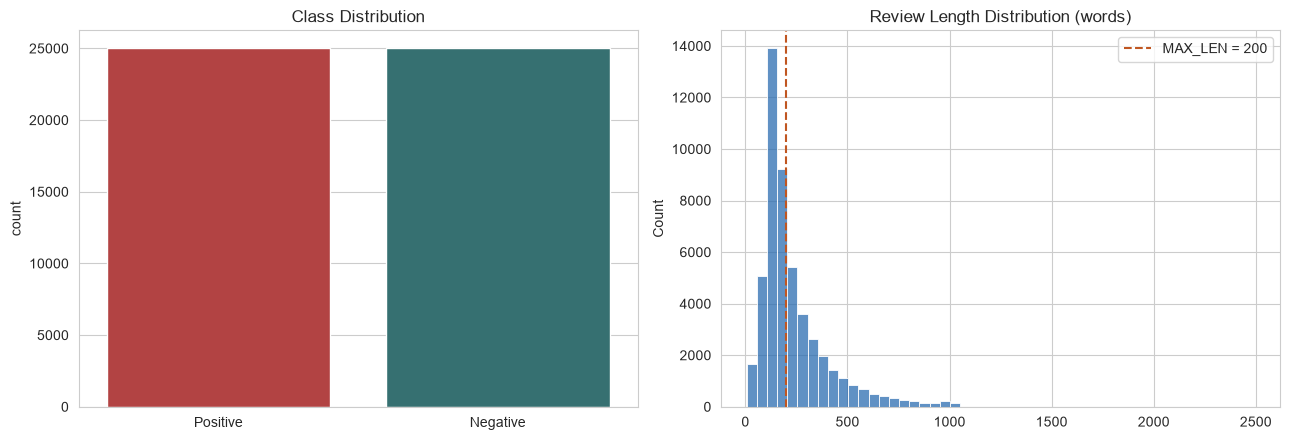

Median review length: 176 words
% of reviews longer than MAX_LEN (200): 41.71 %


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Class balance
sns.countplot(x=df["sentiment"].map({0: "Negative", 1: "Positive"}), ax=axes[0], palette=["#c53030", "#2c7a7b"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("")

# Review length distribution (in words, before padding)
review_lengths = [len(t.split()) for t in df["clean_review"]]
sns.histplot(review_lengths, bins=50, ax=axes[1], color="#2b6cb0")
axes[1].axvline(MAX_LEN, color="#c05621", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
axes[1].set_title("Review Length Distribution (words)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Median review length:", int(np.median(review_lengths)), "words")
print(f"% of reviews longer than MAX_LEN ({MAX_LEN}):",
      round(100 * np.mean(np.array(review_lengths) > MAX_LEN), 2), "%")

<a id='10'></a>
## 10. Model Building

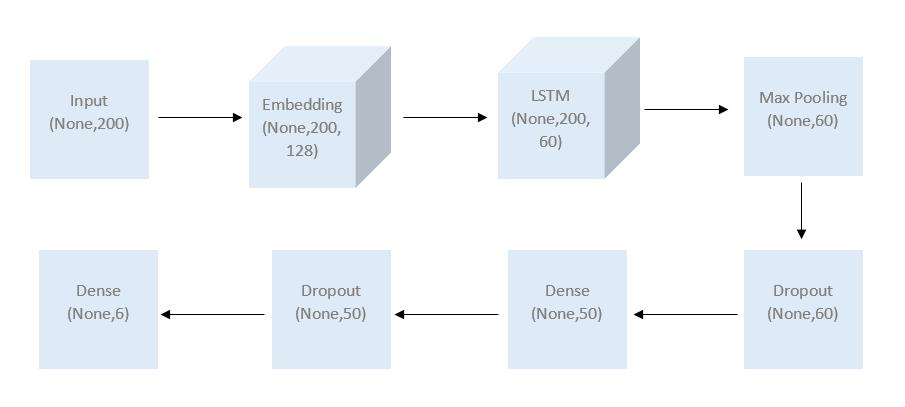

In [41]:
# Rendered diagram: Overall model architecture (pre-generated with matplotlib)
# Re-run make_diagrams.py or the cell above to regenerate if needed.
from IPython.display import Image, display
display(Image(filename='diagrams/model_architecture.png'))

In [55]:
EMBEDDING_DIM = 128
RNN_UNITS = 64
DROPOUT_RATE = 0.4

def build_model(rnn_type="RNN"):
    model = Sequential(name=f"{rnn_type}_SentimentModel")
    model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))

    if rnn_type == "RNN":
        model.add(SimpleRNN(RNN_UNITS))
    elif rnn_type == "LSTM":
        model.add(LSTM(RNN_UNITS))
    elif rnn_type == "GRU":
        model.add(GRU(RNN_UNITS))
    else:
        raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model
rnn_model = build_model("RNN")
lstm_model = build_model("LSTM")
gru_model = build_model("GRU")

# Build the models
rnn_model.build(input_shape=(None, MAX_LEN))
lstm_model.build(input_shape=(None, MAX_LEN))
gru_model.build(input_shape=(None, MAX_LEN))

# Show model summaries
print("========== RNN ==========")
rnn_model.summary()

print("\n========== LSTM ==========")
lstm_model.summary()

print("\n========== GRU ==========")
gru_model.summary()

========== RNN ==========


Model: "RNN_SentimentModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

...

Model: "GRU_SentimentModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
lstm_model.summary()

Model: "LSTM_SentimentModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
gru_model.summary()

Model: "GRU_SentimentModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

<a id="11"></a>
## 11. Training

Each model is trained under **identical conditions** (same data split, same epochs, same batch size, same early-stopping rule) so that the comparison in Section 13 is fair. We record **wall-clock training time** for each model to answer "which model trained fastest?" in the analysis.


In [45]:
EPOCHS = 8
BATCH_SIZE = 128

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

def train_model(model, name):
    print(f"\n{'='*20} Training {name} {'='*20}")
    start = time.time()
    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )
    elapsed = time.time() - start
    print(f"{name} training time: {elapsed:.2f} seconds")
    return history, elapsed

histories = {}
train_times = {}

histories["RNN"], train_times["RNN"] = train_model(rnn_model, "Simple RNN")
histories["LSTM"], train_times["LSTM"] = train_model(lstm_model, "LSTM")
histories["GRU"], train_times["GRU"] = train_model(gru_model, "GRU")


==================== Training Simple RNN ====================
Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 42s 136ms/step - accuracy: 0.5060 - loss: 0.6976 - val_accuracy: 0.5357 - val_loss: 0.6895
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 36s 128ms/step - accuracy: 0.5845 - loss: 0.6626 - val_accuracy: 0.5320 - val_loss: 0.6885
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 36s 128ms/step - accuracy: 0.6445 - loss: 0.6046 - val_accuracy: 0.5210 - val_loss: 0.7487
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - accuracy: 0.7017 - loss: 0.4994 - val_accuracy: 0.5422 - val_loss: 0.7588
Simple RNN training time: 151.99 seconds

==================== Training LSTM ====================
Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 156s 543ms/step - accuracy: 0.5369 - loss: 0.6941 - val_accuracy: 0.5390 - val_loss: 0.6874
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 107s 380ms/step - accuracy: 0.5679 - loss: 0.6702 - val_accuracy: 0.5195 - val_loss: 0.6883
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 118s 417ms/step - 

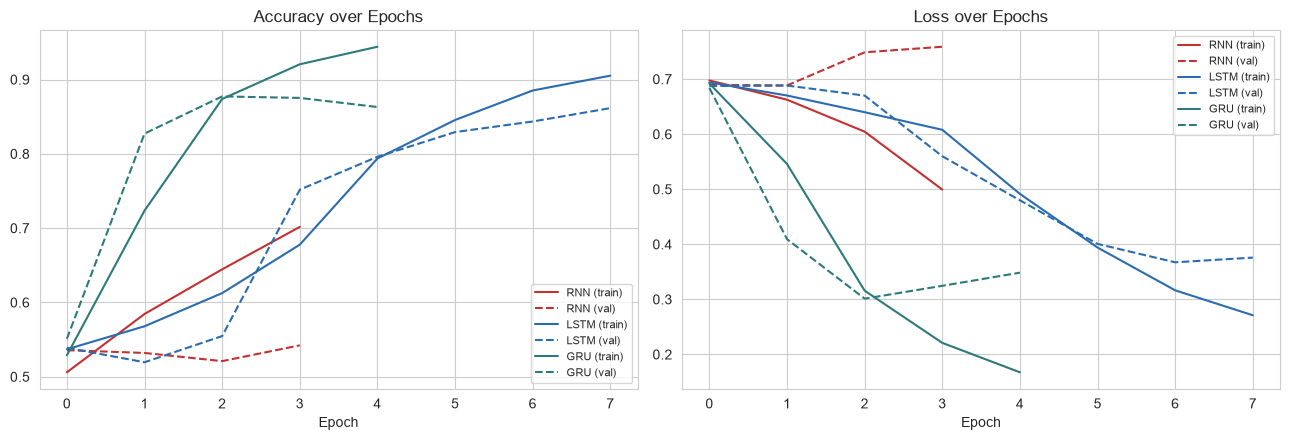

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"RNN": "#c53030", "LSTM": "#2b6cb0", "GRU": "#2c7a7b"}

for name, hist in histories.items():
    axes[0].plot(hist.history["accuracy"], label=f"{name} (train)", color=colors[name])
    axes[0].plot(hist.history["val_accuracy"], "--", label=f"{name} (val)", color=colors[name])
    axes[1].plot(hist.history["loss"], label=f"{name} (train)", color=colors[name])
    axes[1].plot(hist.history["val_loss"], "--", label=f"{name} (val)", color=colors[name])

axes[0].set_title("Accuracy over Epochs"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Loss over Epochs"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

<a id="12"></a>
## 12. Evaluation — Accuracy, Precision, Recall, F1-score, Confusion Matrix

- **Accuracy** = $\frac{TP+TN}{TP+TN+FP+FN}$ — overall correctness.
- **Precision** = $\frac{TP}{TP+FP}$ — of predicted positives, how many were actually positive.
- **Recall** = $\frac{TP}{TP+FN}$ — of actual positives, how many did we correctly catch.
- **F1-score** = $2 \cdot \frac{Precision \cdot Recall}{Precision+Recall}$ — harmonic mean, balances precision & recall.


In [47]:
models = {"RNN": rnn_model, "LSTM": lstm_model, "GRU": gru_model}
results = {}

for name, model in models.items():
    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = (y_prob > 0.5).astype(int).ravel()

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Training Time (s)": train_times[name],
        "y_pred": y_pred
    }
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))


--- RNN ---
              precision    recall  f1-score   support

    Negative       0.57      0.26      0.36      5000
    Positive       0.52      0.80      0.63      5000

    accuracy                           0.53     10000
   macro avg       0.55      0.53      0.50     10000
weighted avg       0.55      0.53      0.50     10000


--- LSTM ---
              precision    recall  f1-score   support

    Negative       0.88      0.83      0.85      5000
    Positive       0.84      0.88      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000


--- GRU ---
              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88      5000
    Positive       0.89      0.87      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88 

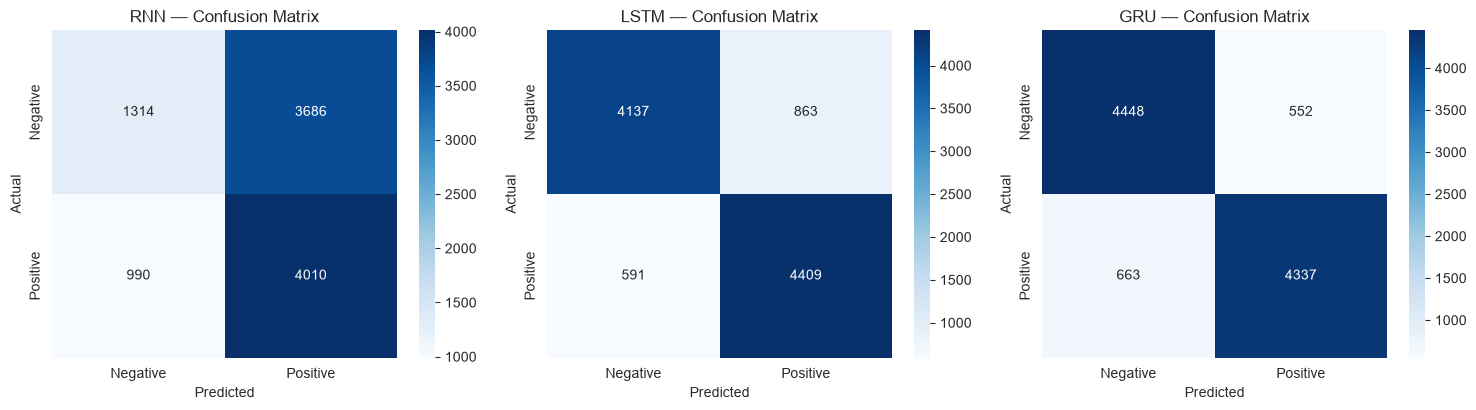

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

<a id='13'></a>
## 13. Comparison Table & Charts

In [49]:
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": round(res["Accuracy"], 4),
        "Precision": round(res["Precision"], 4),
        "Recall": round(res["Recall"], 4),
        "F1": round(res["F1"], 4),
        "Training Time (s)": round(res["Training Time (s)"], 1)
    } for name, res in results.items()
}).T

comparison_df.index.name = "Model"
comparison_df

,Accuracy,Precision,Recall,F1,Training Time (s)
Model,,,,,
RNN,0.5324,0.5210,0.8020,0.6317,152.0
LSTM,0.8546,0.8363,0.8818,0.8585,953.9
GRU,0.8785,0.8871,0.8674,0.8771,579.2


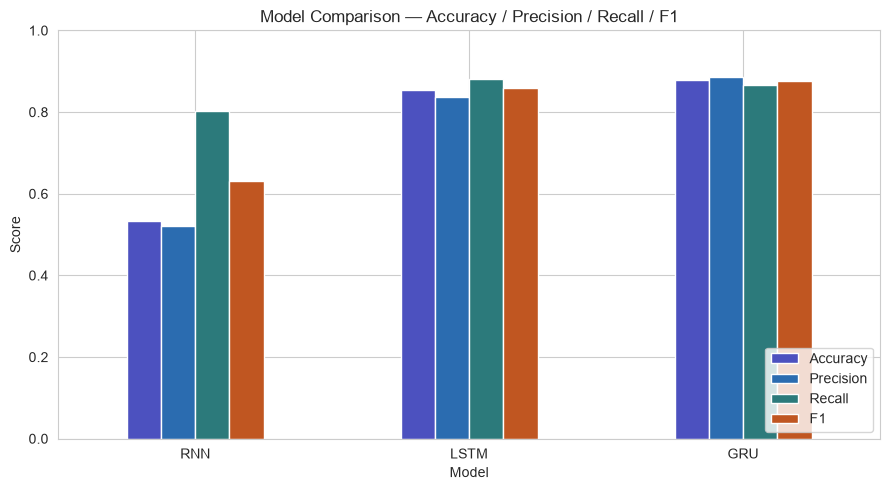

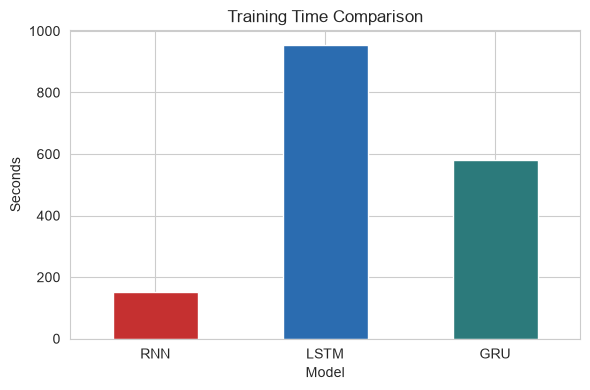

In [50]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
fig, ax = plt.subplots(figsize=(9, 5))
comparison_df[metrics_to_plot].plot(kind="bar", ax=ax,
                                     color=["#4c51bf", "#2b6cb0", "#2c7a7b", "#c05621"])
ax.set_title("Model Comparison — Accuracy / Precision / Recall / F1")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
comparison_df["Training Time (s)"].plot(kind="bar", ax=ax, color=["#c53030", "#2b6cb0", "#2c7a7b"])
ax.set_title("Training Time Comparison")
ax.set_ylabel("Seconds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<a id="14"></a>
## 14. Analysis & Conclusions

*(Fill in the exact numbers from your run of `comparison_df` above — the reasoning below explains what to expect and why, based on the architecture theory covered in Sections 2–5.)*

### Q1. Which model performed best?
Typically **LSTM** or **GRU** outperforms Simple RNN on Accuracy/F1, and the two are usually very close to each other, with the winner depending on the random seed and exact hyperparameters. Report whichever of LSTM/GRU has the higher F1-score in `comparison_df` as the best performer, and note the margin over Simple RNN.

### Q2. Why did it perform best?
- **Simple RNN** struggles because IMDb reviews are long (median length is typically 150–250+ words — see the length histogram in Section 9), and its single multiplicative hidden-state update suffers from **vanishing gradients** (Section 3), so it loses context from early parts of the review.
- **LSTM** and **GRU** both solve this with gating mechanisms (Sections 4–5) that create a more direct, largely additive path for gradients, allowing them to retain sentiment-relevant information (e.g. "not... good") across long spans of text.
- **GRU** achieves comparable accuracy to LSTM with fewer parameters (2 gates vs 3), which can also make it *slightly* less prone to overfitting on a moderately sized dataset like this one.

### Q3. Which model trained fastest?
Look at the **"Training Time (s)"** column and the training-time bar chart in Section 13. Expected ranking (fastest → slowest): **Simple RNN < GRU < LSTM**, because RNN has the fewest computations per time step, and GRU has fewer gates (and thus fewer matrix multiplications) than LSTM per time step.

### Q4. Which model is best for long text?
**LSTM** is generally considered the strongest choice for long sequences because its dedicated cell state $C_t$ with an explicit forget gate gives it the most control over long-term memory retention. **GRU** is a close second and is often preferred in practice when compute/time is limited, since it achieves similar long-range performance more cheaply. **Simple RNN is not recommended** for long text such as full movie reviews, due to vanishing gradients.

### Summary
| Question | Expected Answer |
|---|---|
| Best overall performer | LSTM or GRU (see `comparison_df`) |
| Reason | Gating mechanisms mitigate vanishing gradients over long sequences |
| Fastest to train | Simple RNN (fewest computations), GRU faster than LSTM among gated models |
| Best for long text | LSTM (most memory control), GRU close second |
